In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install torchinfo

# **Import Libraries**

In [2]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import OrderedDict
import platform
import psutil
import random
import glob
from tqdm import tqdm
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ColorJitter, RandomRotation, RandomResizedCrop
from torchvision.transforms.functional import gaussian_blur
from PIL import ImageOps
import seaborn as sns

# **Configuration**

In [3]:
cpu_info = platform.processor()

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    gpu_name = gpu_info[1]
except:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)

CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla T4


# **Variables**

In [21]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
data_dir = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"
output_dir = "/kaggle/working/processed-dataset"  
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)

train_batch = 32
test_batch = 16
total_class = 5 # Sipakmed has 5 classes
learning_rate = 0.0001
decay = 1e-4
epoch = 100
patience = 100

# **Explore Dataset**

In [28]:
def load_sipakmed_data(root_dir):
    file_paths = []
    labels = []
    
    # 1. Define the classes based on the dataset standard
    class_map = {
        'dyskeratotic': 'Dyskeratotic',
        'koilocytotic': 'Koilocytotic',
        'metaplastic': 'Metaplastic',
        'parabasal': 'Parabasal',
        'superficial': 'Superficial'
    }
    
    print(f"Scanning directory: {root_dir}...")
    
    for root, dirs, files in os.walk(root_dir):
        # Normalize path to lowercase for easier matching
        root_lower = root.lower()
        
        if "cropped" in root_lower:
            
            detected_label = None
            for key, val in class_map.items():
                if key in root_lower:
                    detected_label = val
                    break
            
            if detected_label:
                for file in files:
                    if file.lower().endswith(('.bmp', '.jpg', '.png', '.jpeg')):
                        full_path = os.path.join(root, file)
                        file_paths.append(full_path)
                        labels.append(detected_label)

    df = pd.DataFrame({"file_path": file_paths, "label": labels})
    
    if not df.empty:
        df['filename_stem'] = df['file_path'].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
        initial_count = len(df)
        df = df.drop_duplicates(subset=['label', 'filename_stem'])
        df = df.drop(columns=['filename_stem'])
        if len(df) < initial_count:
            print(f"Removed {initial_count - len(df)} duplicate images (same name, diff format).")

    print(f"Total images found: {len(df)}")
    return df

data = load_sipakmed_data(data_dir)

Scanning directory: /kaggle/input/cervical-cancer-largest-dataset-sipakmed...
Total images found: 4049


# **Split Data and Plotting**


Dataset Split Ratios
Train: 2834 images (69.99%)
Test: 608 images (15.02%)
Validation: 607 images (14.99%)


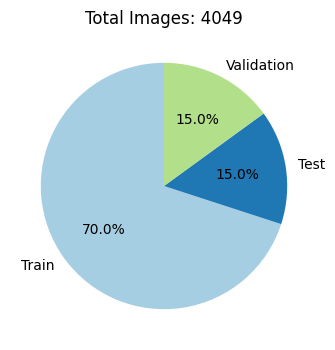

In [29]:
train_dataframe, temp_dataframe = train_test_split(
    data, 
    test_size=0.30, 
    stratify=data['label'], 
    random_state=42
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe, 
    test_size=0.50, 
    stratify=temp_dataframe['label'], 
    random_state=42
)

sizes = {
    "Train": len(train_dataframe),
    "Test": len(test_dataframe),
    "Validation": len(validation_dataframe)
}

total = sum(sizes.values())
ratios = {k: (v / total) * 100 for k, v in sizes.items()}

print("\nDataset Split Ratios")
for split in sizes.keys():
    print(f"{split}: {sizes[split]} images ({ratios[split]:.2f}%)")

plt.figure(figsize=(4, 4))
plt.pie(
    sizes.values(),
    labels=sizes.keys(),
    autopct="%.1f%%",
    startangle=90,
    colors=["#a6cee3", "#1f78b4", "#b2df8a"]
)
plt.title(f"Total Images: {total}")
plt.show()

# **Class Distribution**

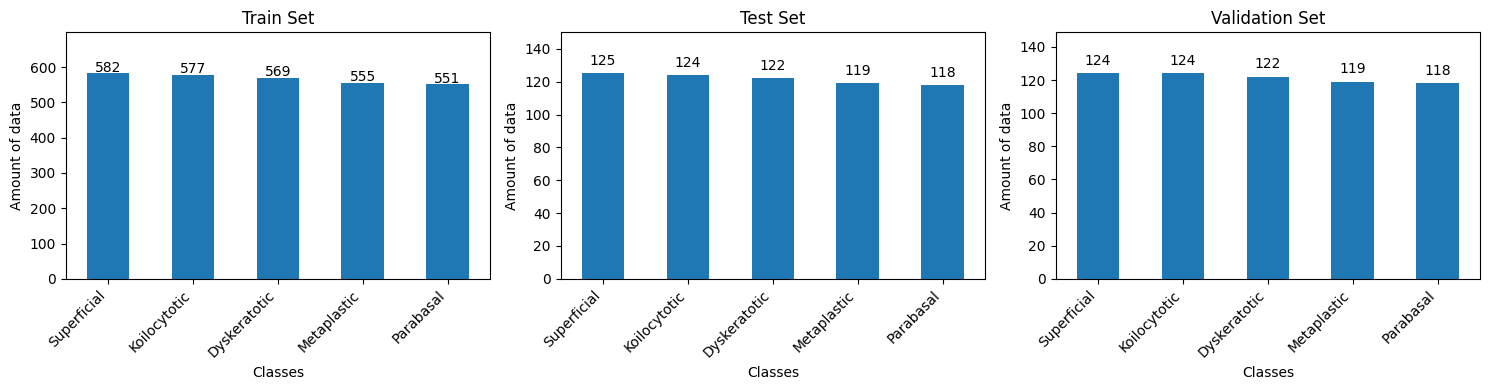

In [30]:
def class_distribution(train_df, test_df, val_df):
    datasets_dict = {
        "Train": train_df,
        "Test": test_df,
        "Validation": val_df
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (split_name, df) in zip(axes, datasets_dict.items()):
        class_counts = df['label'].value_counts()

        class_counts.plot(kind='bar', ax=ax)
        ax.set_xlabel('Classes')
        ax.set_ylabel('Amount of data')
        ax.set_title(f'{split_name} Set')
        ax.set_xticks(range(len(class_counts)))
        ax.set_xticklabels(class_counts.index, rotation=45, ha='right')
        
        for i, count in enumerate(class_counts):
            ax.text(i, count + 5, str(count), ha='center')
        ax.set_ylim(0, max(class_counts) * 1.2)
    
    plt.tight_layout()
    plt.show()

class_distribution(train_dataframe, test_dataframe, validation_dataframe)

# **Data Preprocessing**

In [31]:
def data_preprocess(df, split_name, size=(224, 224), quality=100):
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    processed_file_paths = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        label = row['label']
        label_dir = os.path.join(split_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        try:
            img = Image.open(row['file_path']).convert("RGB")  
            img = img.resize(size, Image.Resampling.LANCZOS)

            file_name = f"{idx}_{os.path.basename(row['file_path'])}"
       
            if not file_name.lower().endswith(('.jpg', '.jpeg')):
                file_name = os.path.splitext(file_name)[0] + ".jpg"
                
            save_path = os.path.join(label_dir, file_name)
            img.save(save_path, optimize=True, quality=quality)

            processed_file_paths.append(save_path)
        except Exception as e:
            print(f"Error processing image {row['file_path']}: {e}")
            # Keep original path if processing fails to avoid crash, or drop
            processed_file_paths.append(row['file_path'])

    df['file_path'] = processed_file_paths
    return df

train_dataframe = data_preprocess(train_dataframe, "train")
validation_dataframe = data_preprocess(validation_dataframe, "val")
test_dataframe = data_preprocess(test_dataframe, "test")

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=False):
        self.dataframe = dataframe
        self.normalize = normalize
        self.is_lb = is_lb
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = PIL.Image.open(img_path).convert("RGB")

        if self.is_lb:
            label = self.label_map[self.dataframe.iloc[index]['label']]
            return self.normalize(image), label
        else:
            return self.normalize(image), self.normalize(image)

def data_transfrom():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomResizedCrop(224, scale=(0.85, 1.1)), # Slightly adjusted for cell images
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.GaussianBlur(kernel_size=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    train_dataset = ImageDataset(train_dataframe, train_transform, is_lb=True)
    valid_dataset = ImageDataset(validation_dataframe, transform, is_lb=True)
    test_dataset = ImageDataset(test_dataframe, transform, is_lb=True)

    print("Label encoding:")
    for label, idx in train_dataset.label_map.items():
        print(f"{label} -> {idx}")
        
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2)
    validation_dataloader = DataLoader(valid_dataset, batch_size=test_batch, shuffle=False, num_workers=2)
    test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2)

    return train_dataloader, validation_dataloader, test_dataloader

train_dataloader, validation_dataloader, test_dataloader = data_transfrom()

Processing test: 100%|██████████| 608/608 [00:06<00:00, 90.61it/s]

Label encoding:
Dyskeratotic -> 0
Koilocytotic -> 1
Metaplastic -> 2
Parabasal -> 3
Superficial -> 4


# **Augmented Samples**

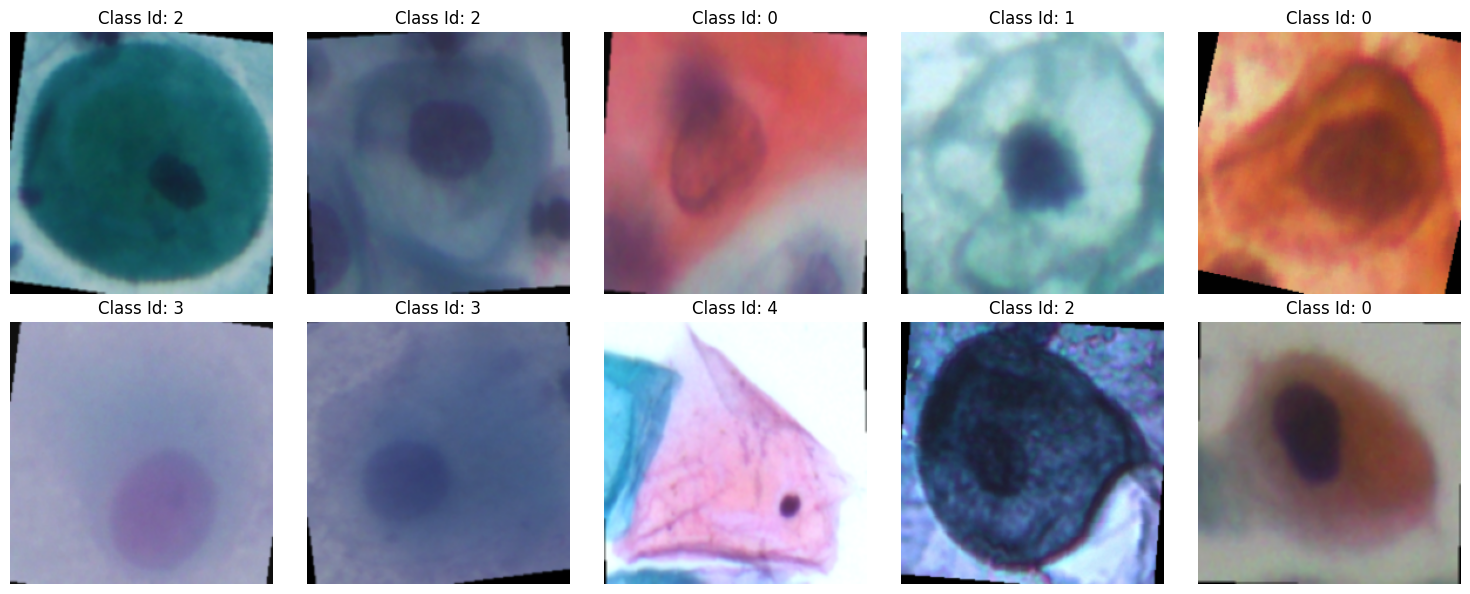

In [32]:
def augmented_samples(dataloader, num_images=10):
    images, labels = next(iter(dataloader))  
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    images = images * std[None, :, None, None] + mean[None, :, None, None]
    images = torch.clamp(images, 0, 1)  

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i, ax in enumerate(axes.flat):
        if i >= num_images: break
        if i < len(images):
            img = images[i].permute(1, 2, 0).cpu().numpy() 
            label = labels[i].item()
            ax.imshow(img)
            ax.set_title(f"Class Id: {label}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

augmented_samples(train_dataloader)

# **Deep Learning Model**

In [34]:
class CervicalCancerNet(nn.Module):
    def __init__(self, num_classes):
        super(CervicalCancerNet, self).__init__()
        
        self.features = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            # Conv Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
            
            # Conv Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 1024), # First Linear Layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)  # Final Linear Layer
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = total_class # 5 classes
model = CervicalCancerNet(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=decay)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(train_batch, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CervicalCancerNet                        [32, 5]                   --
├─Sequential: 1-1                        [32, 512, 7, 7]           --
│    └─Conv2d: 2-1                       [32, 32, 224, 224]        896
│    └─BatchNorm2d: 2-2                  [32, 32, 224, 224]        64
│    └─ReLU: 2-3                         [32, 32, 224, 224]        --
│    └─MaxPool2d: 2-4                    [32, 32, 112, 112]        --
│    └─Conv2d: 2-5                       [32, 64, 112, 112]        18,496
│    └─BatchNorm2d: 2-6                  [32, 64, 112, 112]        128
│    └─ReLU: 2-7                         [32, 64, 112, 112]        --
│    └─MaxPool2d: 2-8                    [32, 64, 56, 56]          --
│    └─Conv2d: 2-9                       [32, 128, 56, 56]         73,856
│    └─BatchNorm2d: 2-10                 [32, 128, 56, 56]         256
│    └─ReLU: 2-11                        [32, 128, 56, 56]         --
│   

# **Training Loop**

In [35]:
start_time = time.time()

def train_model(model, criterion, optimizer, train_dataloader, validation_dataloader, num_epochs=epoch, early_stop_patience=patience, checkpoints_path="checkpoints"):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    best_val_acc = 0.0
    consecutive_no_improvement = 0
    num_epochs_loss_greater = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(enumerate(train_dataloader), total=len(train_dataloader))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss / total_train, acc=correct_train / total_train)
        
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)

        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))

        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in validation_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{checkpoints_path}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")
            consecutive_no_improvement = 0
        else:
            consecutive_no_improvement += 1
            print(f"EARLY STOP COUNTER {consecutive_no_improvement} (NO IMPROVEMENT IN VALIDATION ACCURACY)")

        if epoch_val_loss > epoch_train_loss:
            num_epochs_loss_greater += 1
            print(f"EARLY STOP COUNTER {num_epochs_loss_greater} (VALIDATION LOSS IS HIGHER)")
        else:
            num_epochs_loss_greater = 0

        if consecutive_no_improvement >= early_stop_patience:
            print(f"Early stopping criteria met. No improvement in validation accuracy for {early_stop_patience} consecutive epochs.")
            break

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
    model, criterion, optimizer, train_dataloader, validation_dataloader, checkpoints_path=checkpoints_path
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")

data_log = {
    'Epoch': list(range(1, len(train_loss_history) + 1)),
    'Train Loss': train_loss_history,
    'Train Accuracy': train_acc_history,
    'Validation Loss': val_loss_history,
    'Validation Accuracy': val_acc_history
}

history = pd.DataFrame(data_log)
history.to_excel('/kaggle/working/training_logs.xlsx', index=False)


Epoch 1/100: 100%|██████████| 89/89 [00:14<00:00,  6.04it/s, acc=0.621, loss=1.09]

Training Loss: 1.088 Acc: 0.621


Validation Loss: 0.489 Acc: 0.843
Best model saved at epoch 1 with validation accuracy: 0.843


Epoch 2/100: 100%|██████████| 89/89 [00:14<00:00,  6.26it/s, acc=0.745, loss=0.693]

Training Loss: 0.693 Acc: 0.745


...

Training Loss: 0.109 Acc: 0.960


Validation Loss: 0.152 Acc: 0.946
EARLY STOP COUNTER 27 (NO IMPROVEMENT IN VALIDATION ACCURACY)
EARLY STOP COUNTER 5 (VALIDATION LOSS IS HIGHER)


Epoch 100/100: 100%|██████████| 89/89 [00:14<00:00,  6.22it/s, acc=0.953, loss=0.124]

Training Loss: 0.124 Acc: 0.953


Validation Loss: 0.138 Acc: 0.942
EARLY STOP COUNTER 28 (NO IMPROVEMENT IN VALIDATION ACCURACY)
EARLY STOP COUNTER 6 (VALIDATION LOSS IS HIGHER)
Training Time: 1529.71 seconds ---> 25.50 minutes


# **Visualization**

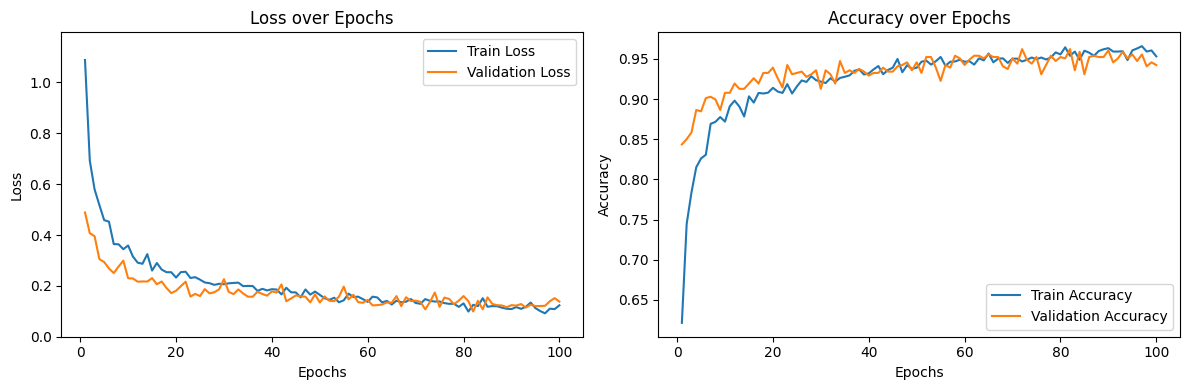

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend(loc='upper right')
if len(train_loss_history) > 0:
    plt.ylim(0, max(max(train_loss_history), max(val_loss_history)) * 1.1)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc_history) + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, len(val_acc_history) + 1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

# **Load Saved Checkpoints**

In [37]:
best_checkpoint_path = f"{checkpoints_path}/model.pt"
checkpoint = torch.load(best_checkpoint_path, map_location=device)
best_epoch = checkpoint["epoch"]

model.load_state_dict(checkpoint["model_weight"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

print(f"Model loaded successfully from Epoch {best_epoch}")

Model loaded successfully from Epoch 72


# **Evaluation**

In [38]:
def evaluate_model(model, criterion, dataloader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

start_time = time.time()

test_loss, test_accuracy = evaluate_model(model, criterion, test_dataloader)
print(f"Test Accuracy: {test_accuracy:.3f}")

end_time = time.time()
test_time = end_time - start_time
print(f"Test Time: {test_time:.2f} seconds ---> {test_time/60:.2f} minutes")

Test Accuracy: 0.951
Test Time: 0.95 seconds ---> 0.02 minutes


In [39]:
def class_accuracy_calc(model, dataloader, num_classes):
    class_correct = [0.0] * num_classes
    class_total = [0.0] * num_classes

    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct = (predicted == labels)
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += correct[i].item()
                class_total[label] += 1

    class_acc_list = [class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(num_classes)]
    return class_acc_list

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_dataloader, desc="Predicting"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial']

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

class_acc = class_accuracy_calc(model, test_dataloader, total_class)
print("\nPer Class Accuracy:")
for i in range(total_class):
    print(f"{class_names[i]}: {class_acc[i]:.3f}")

Predicting: 100%|██████████| 38/38 [00:01<00:00, 37.34it/s]


Classification Report:
              precision    recall  f1-score   support

Dyskeratotic       0.96      0.93      0.95       122
Koilocytotic       0.92      0.87      0.89       124
 Metaplastic       0.93      0.97      0.95       119
   Parabasal       1.00      0.99      1.00       118
 Superficial       0.95      0.98      0.97       125

    accuracy                           0.95       608
   macro avg       0.95      0.95      0.95       608
weighted avg       0.95      0.95      0.95       608




Per Class Accuracy:
Dyskeratotic: 0.934
Koilocytotic: 0.871
Metaplastic: 0.975
Parabasal: 0.992
Superficial: 0.984


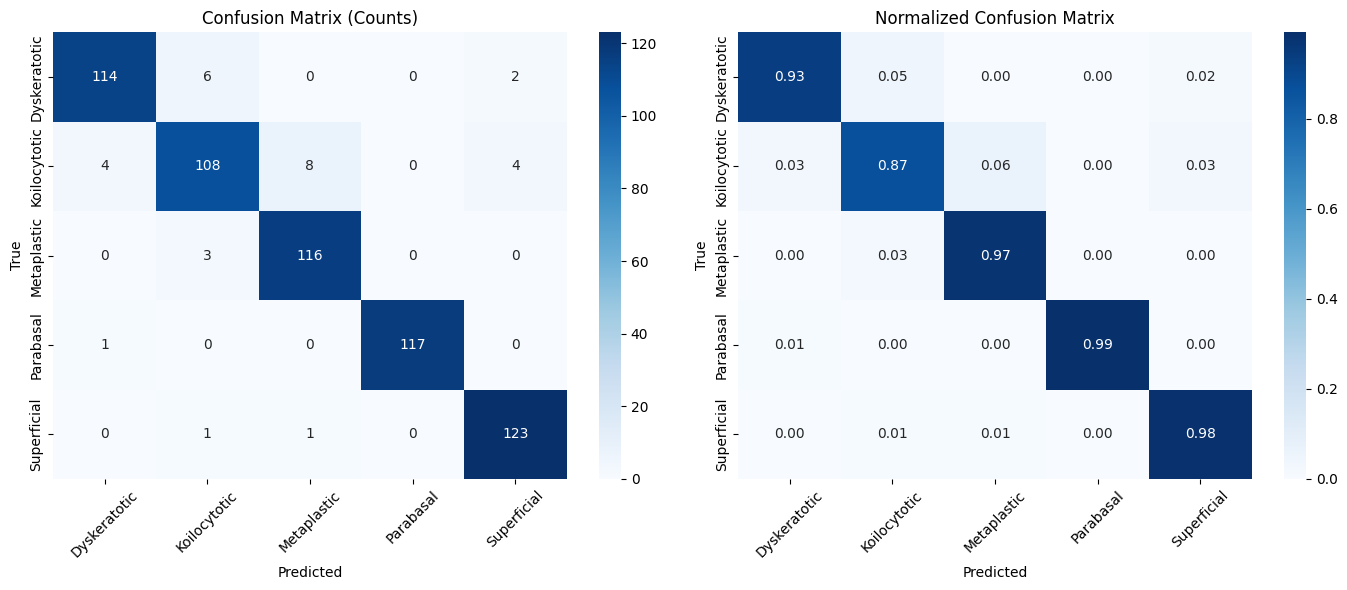

In [40]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Counts)')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()